# Imports

In [2]:
%reload_ext autoreload
%autoreload 2
import seaborn as sns
import anndata as ad 
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from src.helper import *

genesets_dict = get_genesets()
target_genes = np.unique(np.concatenate(list(genesets_dict.values())))

# Dataset 1

In [111]:

par = {
'save_dir' : 'input/full'
}
# - read data


obs = pd.read_csv('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/all_pbmcs/all_pbmcs_metadata.csv', index_col=0)

obs = obs[['Batch', 'Donor_id','Age','Cluster_names', 'Sex']]
obs.columns = ['batch', 'donor_id', 'age', 'cell_type', 'sex']
obs['age_donor'] = obs['age'].astype(str) + '_' + obs['donor_id']

# - remove age over 75
obs = obs[obs.age<=75]

# - binarize to age groups 
bins = [23, 35, 45, 55, 65, 76]  # Define bins for age groups
age_groups = ['34-', '35_44', '45_54', '55_64', '65_75']  # Define corresponding labels
obs['age_group'] = pd.cut(obs['age'], bins=bins, labels=age_groups, right=False)

# - filter samples with low cell counts
sample_size = obs.groupby('age_donor', as_index=False).size()
sample_size = sample_size[sample_size['size']>4000]

obs = obs[obs.age_donor.isin(sample_size.age_donor)]

# - filter for sex 
obs = obs[obs['sex']=='Male']

/vol/tmp/users/jnourisa/ipykernel_3536115/2413928285.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp_plots(obs.groupby('age_group'))


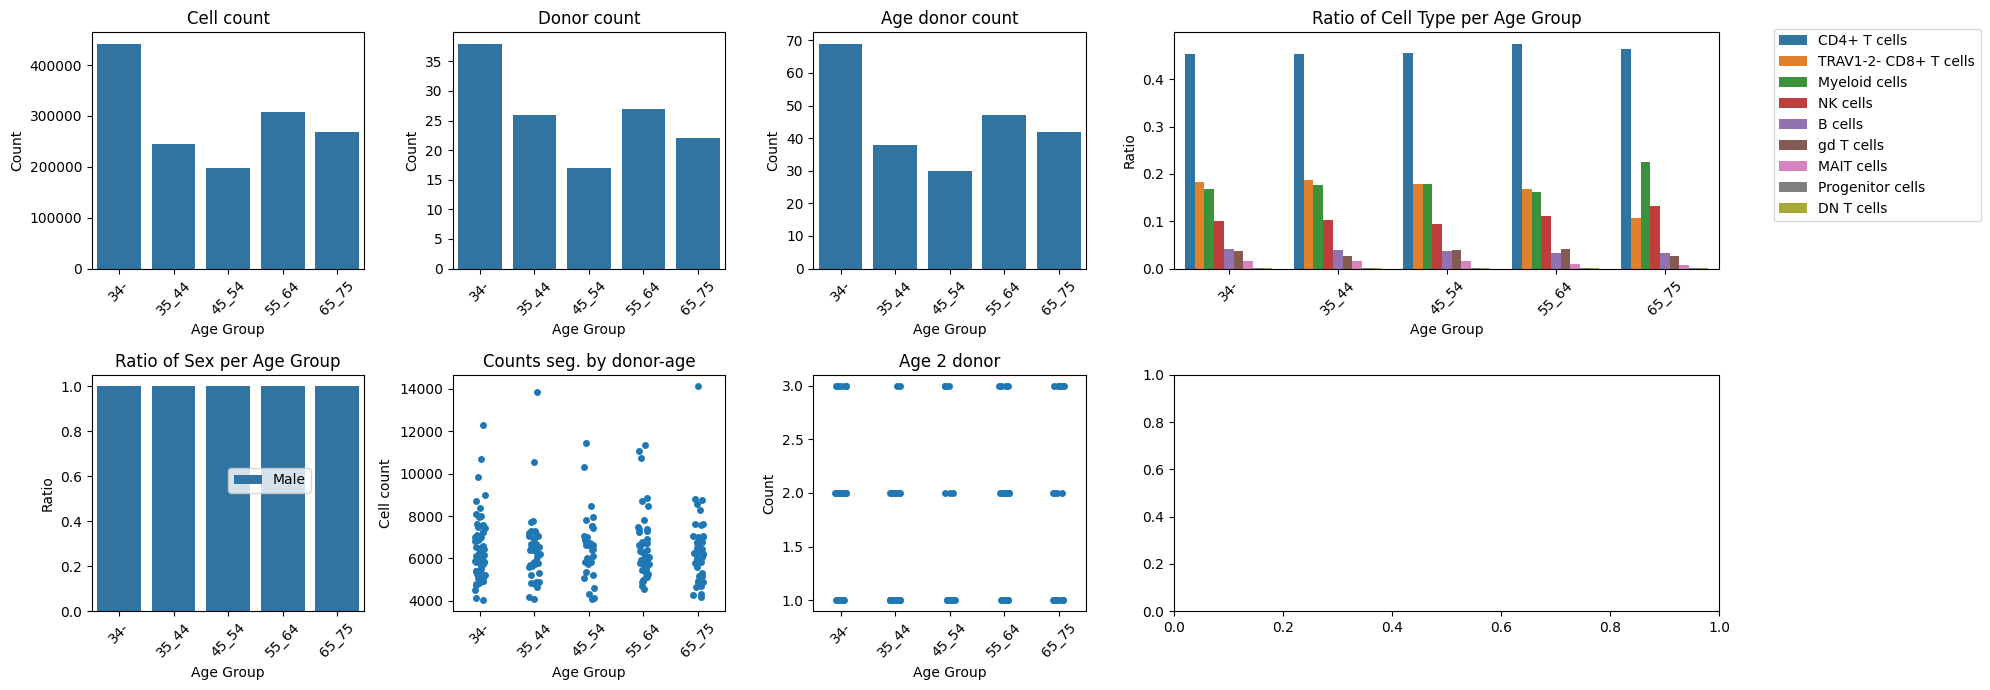

In [112]:
exp_plots(obs.groupby('age_group'))

In [113]:
# - stratified sampling with boostraping 
from sklearn.model_selection import StratifiedGroupKFold

sample_size = 4000  # Desired sample size for large groups
min_cells = obs.groupby('age_donor').size().min()

def stratified_sample_multiple_times(group, sample_size):
    cell_counts = group['cell_type'].value_counts()
    total_cells = len(group)
    samples = []
    
    # Determine how many 4000-cell samples can be drawn
    num_full_samples = total_cells // sample_size
    remaining_cells = total_cells % sample_size  # Remaining cells after full sample extractions
    
    def stratified_sample(group, target_count, replace=False):
        # Same stratified sampling as before
        cell_counts = group['cell_type'].value_counts()
        proportions = cell_counts / cell_counts.sum()
        samples = (proportions * target_count).round().astype(int)
        samples = samples[samples > 0]
        
        sampled_data = []
        for cell_type, n_samples in samples.items():
            sampled_data.append(group[group['cell_type'] == cell_type].sample(n=n_samples, replace=replace))
        return pd.concat(sampled_data)

    # Sample full sets of 4000 cells
    i = 0
    for _ in range(num_full_samples):
        sampled_data = stratified_sample(group, sample_size)
        sampled_data['sample'] = sampled_data['age_donor']+f'_{i}'
        samples.append(sampled_data)
        group = group.drop(sampled_data.index)  # Drop the sampled cells to avoid resampling them
        i+=1
    # print(total_cells, len(samples))
    
    # Sample the remaining cells if any
    # print(sampled_data,remaining_cells)
    if remaining_cells > 3000:
        sampled_data = group
        sampled_data['sample'] = sampled_data['age_donor']+f'_{i}'
        samples.append(sampled_data)
    
    return pd.concat(samples)

obs = obs.groupby('age_donor').apply(lambda x: stratified_sample_multiple_times(x, sample_size)).reset_index(level=0, drop=True)
obs['age_donor'] = obs['sample']


/vol/tmp/users/jnourisa/ipykernel_3536115/1965211971.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  obs = obs.groupby('age_donor').apply(lambda x: stratified_sample_multiple_times(x, sample_size)).reset_index(level=0, drop=True)


/vol/tmp/users/jnourisa/ipykernel_3536115/2413928285.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp_plots(obs.groupby('age_group'))


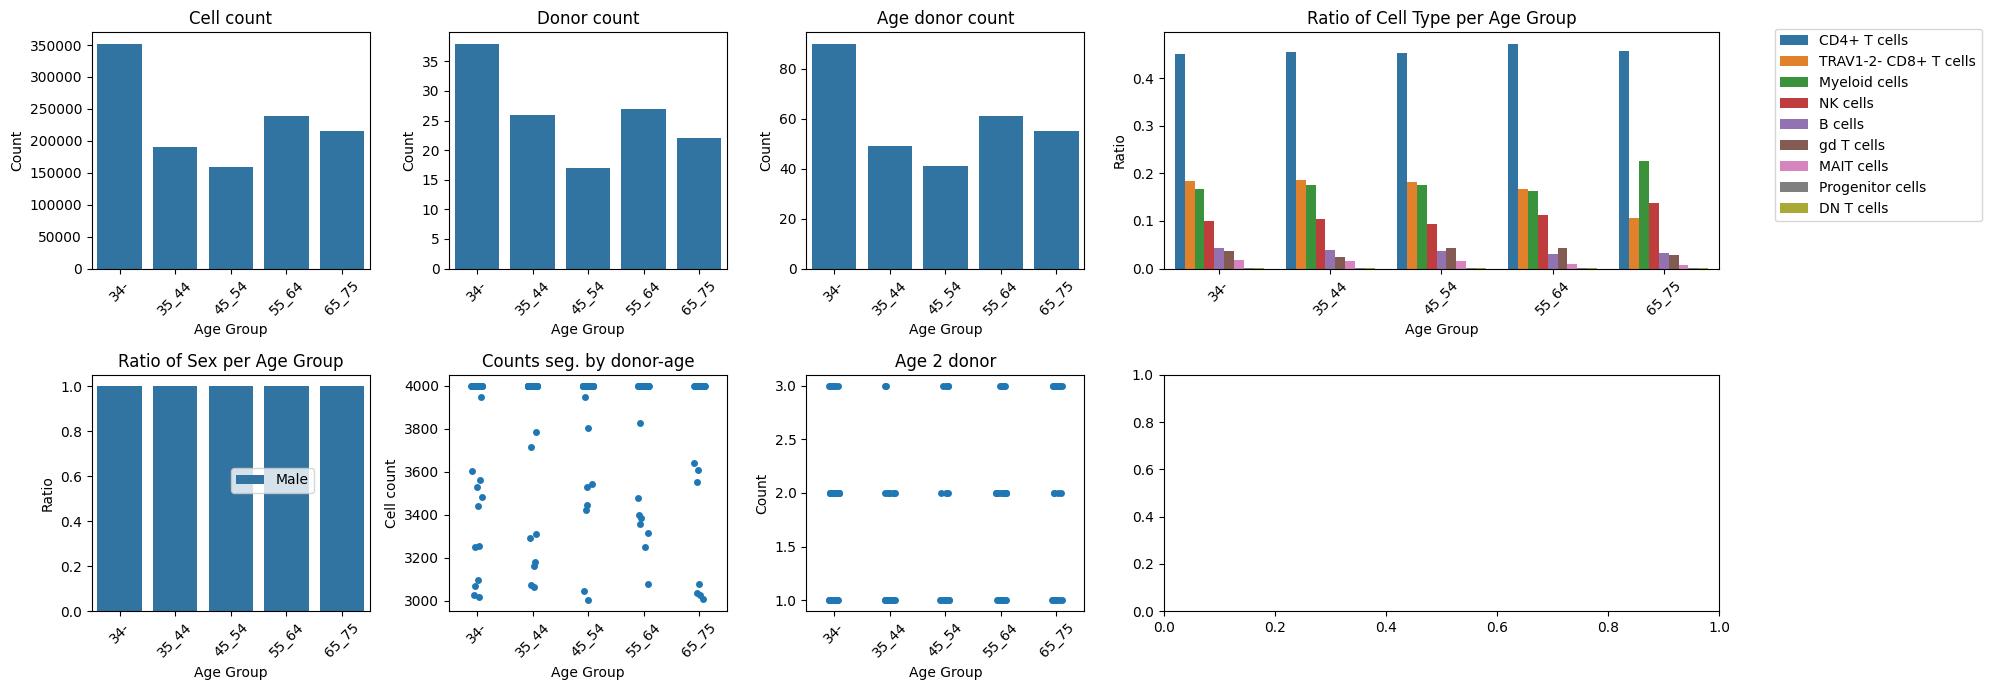

In [114]:
exp_plots(obs.groupby('age_group'))

In [115]:
# -- equalize donor_age size for each age_group
set_donor_size = 25
n_groups = 2 
donor_size_per_group =  n_groups*set_donor_size
def reduce_donors(ss):

    if ss.nunique() >= donor_size_per_group:
        ss = np.random.choice(ss.unique(), size=donor_size_per_group, replace=False)
    else:
        pass
    return ss
donors_f = obs.groupby('age_group')['age_donor'].apply(reduce_donors)
obs = obs[obs.age_donor.isin(np.concatenate(donors_f.values))]
obs

/vol/tmp/users/jnourisa/ipykernel_3536115/1982707980.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donors_f = obs.groupby('age_group')['age_donor'].apply(reduce_donors)


,batch,donor_id,age,cell_type,sex,age_donor,age_group,sample
ALAW-AS056-1_TACGGATCACGACGAA-1,AS056,A15,25,TRAV1-2- CD8+ T cells,Male,25_A15_0,34-,25_A15_0
ALAW-AS056-1_TGACAACGTCATCGGC-1,AS056,A15,25,TRAV1-2- CD8+ T cells,Male,25_A15_0,34-,25_A15_0
ALAW-AS056-1_GAACGGAAGAGTCTGG-1,AS056,A15,25,TRAV1-2- CD8+ T cells,Male,25_A15_0,34-,25_A15_0
ALAW-AS056-2_CTCGTACAGTGACATA-1,AS056,A15,25,TRAV1-2- CD8+ T cells,Male,25_A15_0,34-,25_A15_0
ALAW-AS056-1_TCTTCGGAGTCCGGTC-1,AS056,A15,25,TRAV1-2- CD8+ T cells,Male,25_A15_0,34-,25_A15_0
...,...,...,...,...,...,...,...,...
ALAW-AS058-2_TCTCTAAGTGACAAAT-1,AS058,E22,75,gd T cells,Male,75_E22_0,65_75,75_E22_0
ALAW-AS058-2_TTGCCGTAGAGCTATA-1,AS058,E22,75,gd T cells,Male,75_E22_0,65_75,75_E22_0
ALAW-AS058-2_CATATTCGTTTCCACC-1,AS058,E22,75,gd T cells,Male,75_E22_0,65_75,75_E22_0
ALAW-AS058-1_GAATAAGTCTGACCTC-1,AS058,E22,75,DN T cells,Male,75_E22_0,65_75,75_E22_0


In [116]:
def assign_batches(group):
    unique_donors = group['donor_id'].unique()
    np.random.shuffle(unique_donors)
    
    n_half = int(len(unique_donors) / 2)
    batch1 = unique_donors[:n_half]
    batch2 = unique_donors[n_half:]

    batch_names = ['batch_1'] * n_half + ['batch_2'] * (len(unique_donors) - n_half)
    map_donor_to_batch = {donor: batch for donor, batch in zip(unique_donors, batch_names)}
    group['batch_group'] = group['donor_id'].map(map_donor_to_batch)
    
    return group

obs = obs.groupby('age_group', group_keys=False).apply(assign_batches)
obs.shape

/vol/tmp/users/jnourisa/ipykernel_3536115/314216862.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs = obs.groupby('age_group', group_keys=False).apply(assign_batches)
/vol/tmp/users/jnourisa/ipykernel_3536115/314216862.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  obs = obs.groupby('age_group', group_keys=False).apply(assign_batches)


(937240, 9)

/vol/tmp/users/jnourisa/ipykernel_3536115/2413928285.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp_plots(obs.groupby('age_group'))


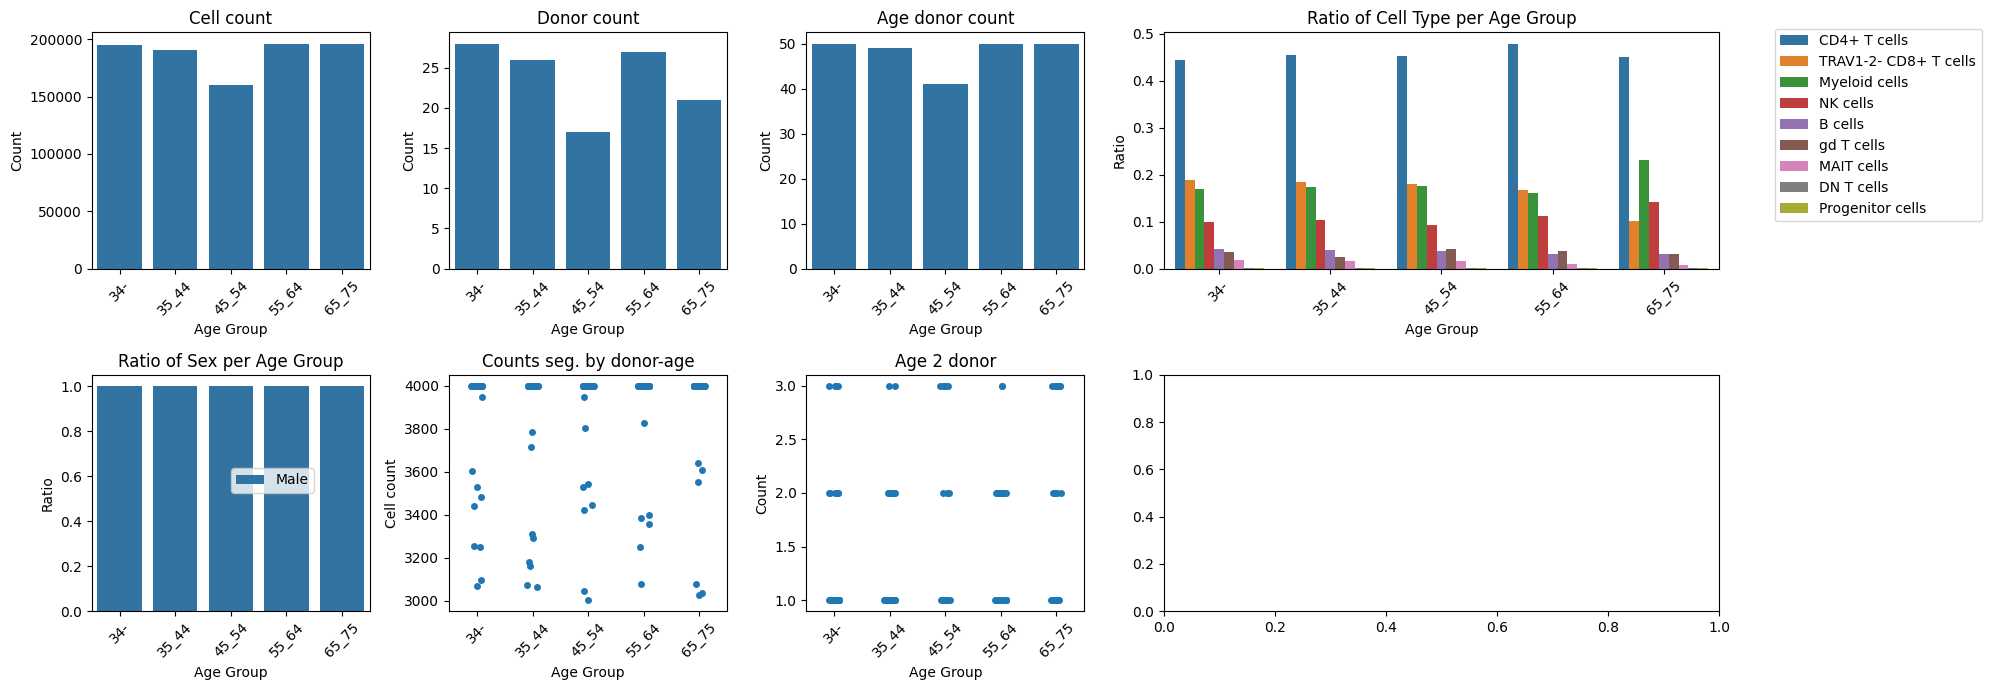

In [117]:
exp_plots(obs.groupby('age_group'))

In [118]:
# adata = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/raw_counts_h5ad/pbmc_gex_raw_with_var_obs.h5ad')

for i, age_group in enumerate(obs['age_group'].unique()):
    obs_sub = obs[obs['age_group'] == age_group]
    adata_sub = adata[adata.obs.index.isin(obs_sub.index)]
    adata_sub = basic_qc(adata_sub, min_genes_per_cell = 200, max_genes_per_cell = 5000, min_cells_per_gene = 1000)
    
    if i == 0:
        adata_all = adata_sub
    else:
        adata_all = ad.concat([adata_sub, adata_all], axis=0)
    print(adata_all)


shape before  (194677, 36601)
shape after  (194677, 12789)
View of AnnData object with n_obs × n_vars = 194677 × 12789
    obs: 'nCount_RNA', 'nFeature_RNA', 'Cluster_names'
    uns: 'Cluster_names_colors'
shape before  (190584, 36601)
shape after  (190584, 12642)
AnnData object with n_obs × n_vars = 385261 × 12599
    obs: 'nCount_RNA', 'nFeature_RNA', 'Cluster_names'
shape before  (159748, 36601)
shape after  (159748, 12056)
AnnData object with n_obs × n_vars = 545009 × 12051
    obs: 'nCount_RNA', 'nFeature_RNA', 'Cluster_names'
shape before  (196290, 36601)
shape after  (196290, 12652)
AnnData object with n_obs × n_vars = 741299 × 12049
    obs: 'nCount_RNA', 'nFeature_RNA', 'Cluster_names'
shape before  (195941, 36601)
shape after  (195941, 12844)
AnnData object with n_obs × n_vars = 937240 × 12044
    obs: 'nCount_RNA', 'nFeature_RNA', 'Cluster_names'


In [119]:
adata_all.obs = adata_all.obs.merge(obs, left_index=True, right_index=True, how='left', suffixes=['','_'])
adata_all.obs = adata_all.obs[['batch', 'donor_id', 'age', 'cell_type', 'sex', 'age_donor', 'age_group', 'batch_group']]

In [120]:
adata_all.write('input/adata_bootstrapped.h5ad') 

In [121]:
aa

NameError: name 'aa' is not defined

## Normalize

In [12]:

import seaborn as sns
import anndata as ad 
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from src.helper import *

adata_all = ad.read_h5ad('input/adata.h5ad')

adata_all.layers['counts'] = adata_all.X.copy()

for i, age_donor in enumerate(adata_all.obs.age_donor.unique()):
    adata_sub = adata_all[adata_all.obs.age_donor==age_donor]
    adata_sub = basic_qc(adata_sub, min_genes_per_cell=10, min_cells_per_gene=100)

    # - normalize apr 
    adata_sub.X = adata_sub.layers['counts'].copy()
    sc.experimental.pp.normalize_pearson_residuals(adata_sub)
    adata_sub.layers['apr'] = adata_sub.X.copy()

    # - normalize sla
    adata_sub.X = adata_sub.layers['counts'].copy()
    sc.pp.normalize_total(adata_sub)
    sc.pp.log1p(adata_sub)
    adata_sub.layers['sla'] = adata_sub.X.copy()
    
    if i == 0:
        adata_sub_all = adata_sub
    else:
        adata_sub_all = ad.concat([adata_sub_all, adata_sub], axis=0)
adata_sub_all.write('input/adata_n.h5ad')

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 11341 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


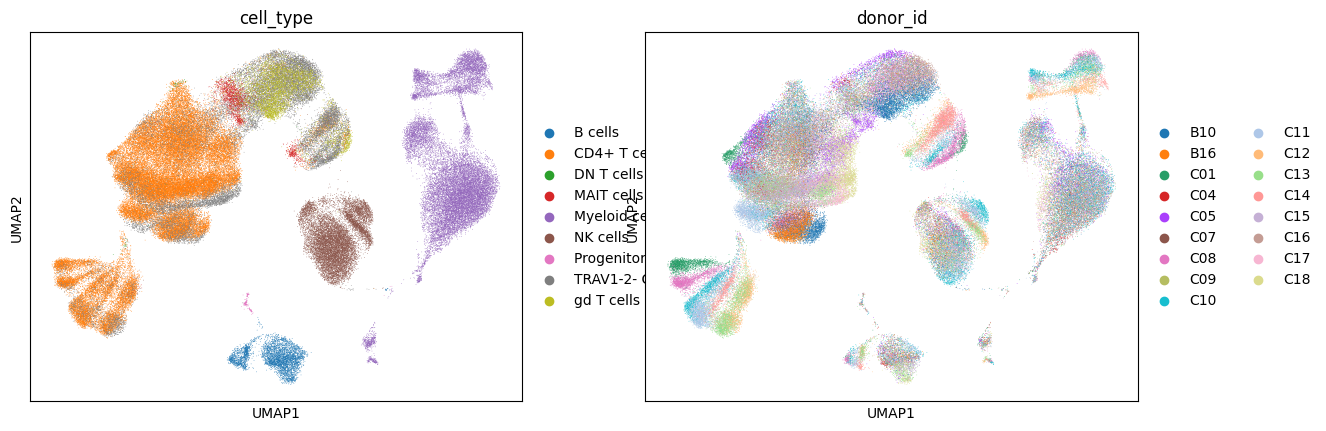

In [10]:
adata_sub_sla = adata_all[adata_all.obs.age_group=='65_75', :]
# - umap 
if True:
    sc.pp.normalize_total(adata_sub_sla)
    sc.pp.log1p(adata_sub_sla)

sc.pp.neighbors(adata_sub_sla)
sc.tl.umap(adata_sub_sla)
sc.pl.umap(adata_sub_sla, color=['cell_type', 'donor_id'])

In [10]:
adata_sub_apr_n

AnnData object with n_obs × n_vars = 122132 × 11341
    obs: 'batch', 'donor_id', 'age', 'cell_type', 'sex', 'age_donor', 'age_group', 'batch_group'

shape before  (4070, 11341)
shape after  (4070, 6921)


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/experimental/pp/_normalization.py:134: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


shape before  (4072, 11341)
shape after  (4072, 7762)


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/experimental/pp/_normalization.py:134: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


shape before  (4071, 11341)
shape after  (4071, 7277)


...

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/experimental/pp/_normalization.py:134: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


shape before  (4072, 11341)
shape after  (4072, 9534)


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/experimental/pp/_normalization.py:134: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


shape before  (4073, 11341)
shape after  (4073, 9152)


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/experimental/pp/_normalization.py:134: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 6093 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


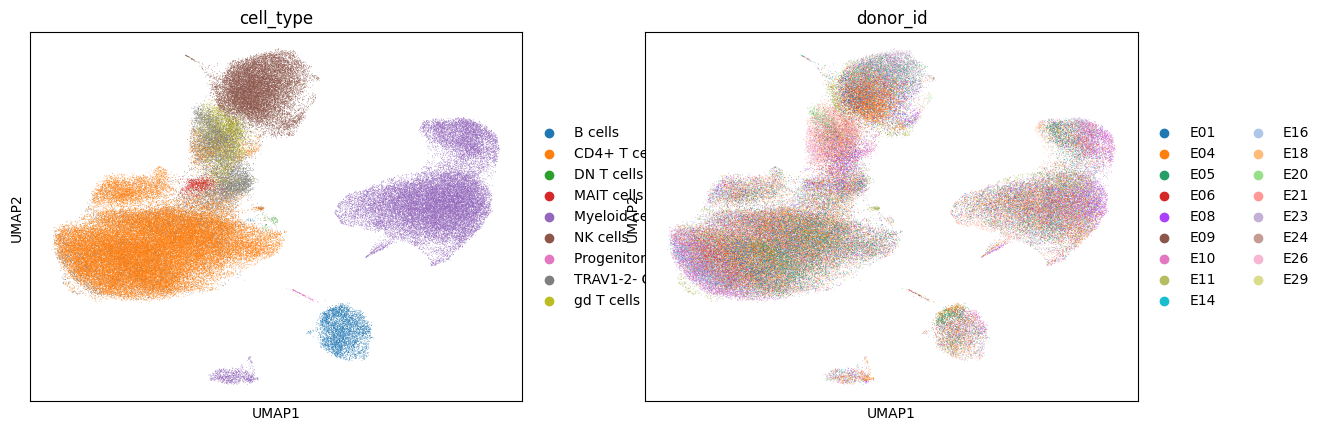

In [11]:
adata_sub_apr = adata_all[adata_all.obs.age_group=='65_75', :]

for i, age_donor in enumerate(adata_sub_apr.obs.age_donor.unique()):
    adata_sub_apr_a = adata_sub_apr[adata_sub_apr.obs.age_donor==age_donor]
    adata_sub_apr_a = basic_qc(adata_sub_apr_a, min_genes_per_cell=10, min_cells_per_gene=100)
    sc.experimental.pp.normalize_pearson_residuals(adata_sub_apr_a)
    
    if i == 0:
        adata_sub_apr_n = adata_sub_apr_a
    else:
        adata_sub_apr_n = ad.concat([adata_sub_apr_a, adata_sub_apr_n], axis=0)

sc.pp.neighbors(adata_sub_apr_n)
sc.tl.umap(adata_sub_apr_n)
sc.pl.umap(adata_sub_apr_n, color=['cell_type', 'donor_id'])

# Dataset 2

In [1]:
!ls /vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/

data10_CMtx.h5ad      data2_var.csv	   data6_obs.csv
data10_CMtx.h5Seurat  data3_CMtx.h5ad	   data6_var.csv
data10_CMtx.rds       data3_CMtx.h5Seurat  data7_CMtx.h5ad
data10_obs.csv	      data3_CMtx.rds	   data7_CMtx.h5Seurat
data10_var.csv	      data3_obs.csv	   data7_CMtx.rds
data11_CMtx.h5ad      data3_var.csv	   data7_obs.csv
data11_CMtx.h5Seurat  data4_CMtx.h5ad	   data7_var.csv
data11_CMtx.rds       data4_CMtx.h5Seurat  data8_CMtx.h5ad
data11_obs.csv	      data4_CMtx.rds	   data8_CMtx.h5Seurat
data11_var.csv	      data4_obs.csv	   data8_CMtx.rds
data1_CMtx.h5ad       data4_var.csv	   data8_obs.csv
data1_CMtx.h5Seurat   data5_CMtx.h5ad	   data8_var.csv
data1_CMtx.rds	      data5_CMtx.h5Seurat  data9_CMtx.h5ad
data1_obs.csv	      data5_CMtx.rds	   data9_CMtx.h5Seurat
data1_var.csv	      data5_obs.csv	   data9_CMtx.rds
data2_CMtx.h5ad       data5_var.csv	   data9_obs.csv
data2_CMtx.h5Seurat   data6_CMtx.h5ad	   data9_var.csv
data2_CMtx.rds	      data6_CMtx.h5Seurat
data2_obs.csv	   

In [36]:
# adata  = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/data1_CMtx.h5ad')
obs = adata.obs

obs = obs[['batch_info', 'donor_id','age','ct_major_published', 'sex']]
obs.columns = ['batch', 'donor_id', 'age', 'cell_type', 'sex']
obs['sex'] = obs['sex'].str.replace('M', 'Male')
obs['sex'] = obs['sex'].str.replace('F', 'Female')
obs['age_donor'] = obs['age'].astype(str) + '_' + obs['donor_id']

# - remove age over 75
obs = obs[obs.age<75]

# - binarize to age groups 
bins = [23, 35, 45, 55, 65, 75]  # Define bins for age groups
age_groups = ['34-', '35_44', '45_54', '55_64', '65_75']  # Define corresponding labels
obs['age_group'] = pd.cut(obs['age'], bins=bins, labels=age_groups, right=False)

/vol/tmp/users/jnourisa/ipykernel_473767/2829591640.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['sex'] = obs['sex'].str.replace('M', 'Male')
/vol/tmp/users/jnourisa/ipykernel_473767/2829591640.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['sex'] = obs['sex'].str.replace('F', 'Female')
/vol/tmp/users/jnourisa/ipykernel_473767/2829591640.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

/vol/tmp/users/jnourisa/ipykernel_473767/1049297395.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp_plots(obs.groupby('age_group'), cell_type=False)


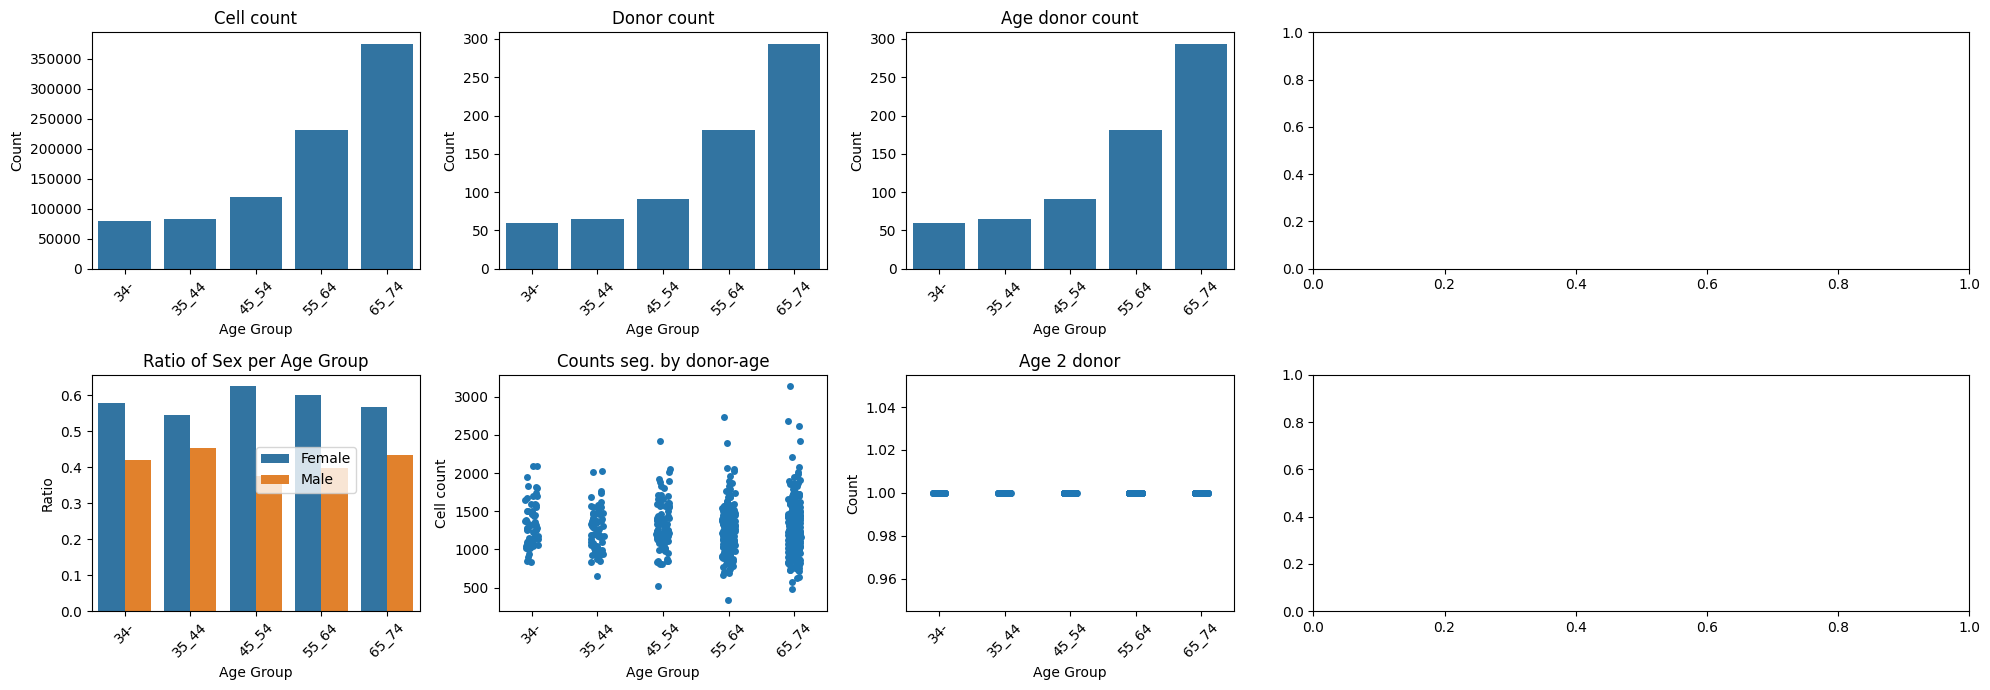

In [33]:
exp_plots(obs.groupby('age_group'), cell_type=False)

In [37]:
# - filter samples with low cell counts
sample_size = obs.groupby('age_donor', as_index=False).size()
sample_size = sample_size[sample_size['size']>1500]

obs = obs[obs.age_donor.isin(sample_size.age_donor)]
# - filter for sex 
obs = obs[obs['sex']=='Male']

In [35]:
obs

,batch,donor_id,age,cell_type,sex,age_donor,age_group
AAACCTGAGAATGTTG-1,Data1_1,Data1_691_692,66,CD4TCM,Male,66_Data1_691_692,65_74
AAACCTGAGCATGGCA-1,Data1_1,Data1_688_689,66,CD4Naive,Male,66_Data1_688_689,65_74
AAACCTGCAAATTGCC-1,Data1_1,Data1_688_689,66,CD4Naive,Male,66_Data1_688_689,65_74
AAACCTGCAAGACGTG-1,Data1_1,Data1_689_690,59,CD4Naive,Male,59_Data1_689_690,55_64
AAACCTGCACACGCTG-1,Data1_1,Data1_688_689,66,CD4Naive,Male,66_Data1_688_689,65_74
...,...,...,...,...,...,...,...
TTTGTCAAGATGCGAC-8,Data1_8,Data1_744_745,63,CD4Naive,Male,63_Data1_744_745,55_64
TTTGTCAAGTTTCCTT-8,Data1_8,Data1_744_745,63,CD4Naive,Male,63_Data1_744_745,55_64
TTTGTCACACAACTGT-8,Data1_8,Data1_744_745,63,NK,Male,63_Data1_744_745,55_64
TTTGTCACATGGATGG-8,Data1_8,Data1_744_745,63,CD4TCM,Male,63_Data1_744_745,55_64


/vol/tmp/users/jnourisa/ipykernel_473767/1049297395.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp_plots(obs.groupby('age_group'), cell_type=False)


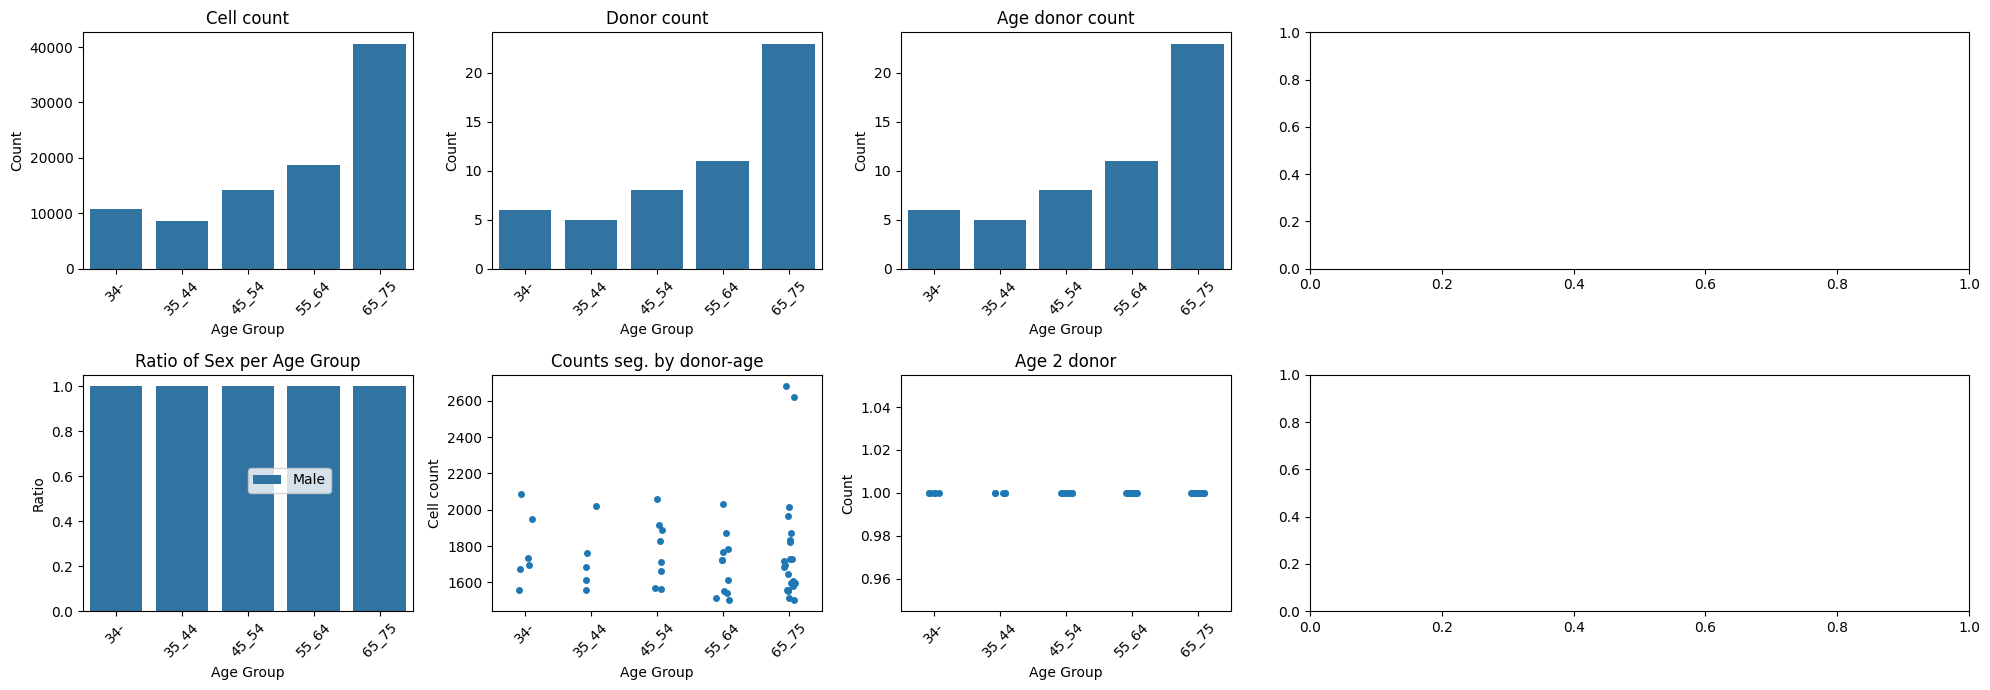

In [38]:
exp_plots(obs.groupby('age_group'), cell_type=False)